# Lista de Exercício 4
### Introdução à Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste de 5 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminado os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado, o aluno ficará sem nota.


---


 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_4.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_4.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>


`Nome: Marcus Vinícius Costa Reis`

`Número USP: 12549384`

### Introdução:


Vamos importar as bibliotecas que iremos utilizar:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd

from skimage.feature import local_binary_pattern

#### **Atenção**: os códigos abaixo são para fazer o download das imagens (EXECUTE-OS). Os mesmos não fazem parte dessa prática.

In [2]:
import urllib.request

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/triangulo.png", "triangulo.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/estrela.png", "estrela.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/folha_ferrugem.png", "folha_ferrugem.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")


try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/folha_saudavel.png", "folha_saudavel.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/guitarra.png", "guitarra.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/banjo.png", "banjo.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/violao.png", "violao.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex3.tiff", "tex3.tiff")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex2.tiff", "tex2.tiff")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex1.tiff", "tex1.tiff")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex4.tiff", "tex4.tiff")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/circulo1.tif", "circulo1.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/circulo2.tif", "circulo2.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/quadrado1.tif", "quadrado1.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/quadrado2.tif", "quadrado2.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")



### 1) Momentos (Nota: 1.5/10)

A equação generalizada para o cálculo do momento $m_{pq}$ é dada por:

\begin{equation}
m_{pq} = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty} x^p y^q \, f(x,y) \, dx dy, \end{equation}

onde $f(x,y)$ é a imagem, $x$ e $y$ suas respectivas coordenadas. Seguindo a teoria de momentos, as coordenadas do centro de massa normalizado de um objeto podem ser determinadas utilizando as seguintes equações:

\begin{equation}
  \bar{x} = \frac{m_{10}}{m_{00}}
  \;\;\;
  \bar{y} = \frac{m_{01}}{m_{00}}
\end{equation}

<center><figure class="half" style="display:flex">
    <img width="256" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/triangulo.png">
    <img width="256" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/estrela.png">
    <figcaption><b> Figura 1: </b> Da esquerda para a direita: <i>triangulo.png</i> e <i>estrela.png</i>.</b></figcaption>
</figure></center>

**Exercício:**

1. Construa uma função chamada `momentos` que, dado uma imagem de entrada, retorne todos os momentos $m_{pq}$, com p e q variando de 0 a 1, isto é, que compute os 4 momentos: $m_{00}$, $m_{01}$, $m_{10}$ e $m_{11}$;

2. Utilizando a função `momentos` e o equacionamento descrito acima, determine as coordenadas do centro de massa dos objetos das figuras `triangulo.png` e `estrela.png`.

3. Plote um '+' no centro de massa, utilizando `plt.plot` após mostrar a imagem.
``` python
# Mostra a imagem
plt.imshow(myImg, 'gray')
# Coloca um '+' no centro de massa
plt.plot(ic, jc, '+')
```

3. Rotacione a imagem `triangulo.png` em $90^{\circ}$ no sentido horário.
  * Para rotacionar a imagem, utilize a função [cv.rotate] passando como argumento `cv.ROTATE_90_CLOCKWISE`
``` python
myImg_rot = cv.rotate(myImg, cv.ROTATE_180)
```

4. Repita o procedimento dos itens 2 e 3. Comente a respeito.


Coordenadas do CM do triângulo: (x = 297.0101148456432, y = 250.41302286376566)
Coordenadas do CM da estrela: (x = 239.27100247087893, y = 256.77647370278856)


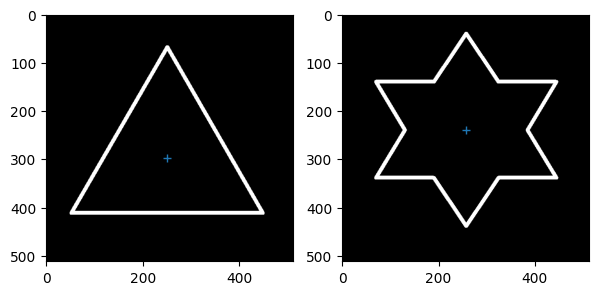

Coordenadas do CM do triângulo: (x = 250.41302286376566, y = 213.98988515435676)


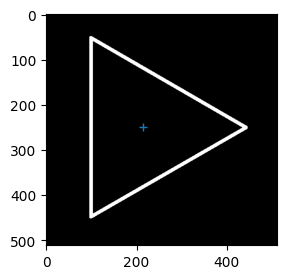

In [3]:
## -- Seu código começa AQUI -- ##

# Item 1 ------------------------------------------------------------------

def momentos(img):
  '''
  Descrição: Calcula os momentos da imagem img.

  Entrada:
    - img: Imagem de entrada.

  Saída:
    - res: Lista m contendo os 4 momentos da imagem.
  '''

  m = list()  # Lista que armazenará os 4 momentos da imagem

  for p in range(2):     # p varia de 0 a 1
    for q in range(2):   # q varia de 0 a 1

      mpq = 0

      # Calculando a integral dupla
      for y in range(img.shape[1]):     # Percorrendo a largura da img
        for x in range(img.shape[0]):   # Percorrendo a altura da img

          mpq += (x**p)*(y**q)*img[x, y]

      m.append(mpq)

  return m

# Item 2 ----------------------------------------------------------------

# Carregando as imagens
triangulo = cv.imread('triangulo.png', cv.IMREAD_GRAYSCALE)  # Triângulo
estrela = cv.imread('estrela.png', cv.IMREAD_GRAYSCALE)      # Estrela

# Obtendo os momentos de cada imagem
mt = momentos(triangulo)
me = momentos(estrela)

# Calculando os centros de massa para cada imagem
cmt = [mt[2]/mt[0], mt[1]/mt[0]]  # CM Triângulo
cem = [me[2]/me[0], me[1]/me[0]]  # CM Estrela

it, jt = cmt[0], cmt[1]  # Coordenadas CM triângulo
ie, je = cem[0], cem[1]  # Coordenadas CM estrela

print(f'Coordenadas do CM do triângulo: (x = {it}, y = {jt})')
print(f'Coordenadas do CM da estrela: (x = {ie}, y = {je})')

# Item 3 ----------------------------------------------------------------

# Plotando as imagens com um '+' no CM de cada uma

plt.figure(figsize=(7, 4))

# Triângulo
plt.subplot(1, 2, 1)
plt.imshow(triangulo, 'gray')  # Mostrando a imagem
plt.plot(jt, it, '+')          # Colocando um '+' no centro de massa

# Estrela
plt.subplot(1, 2, 2)
plt.imshow(estrela, 'gray')  # Mostrando a imagem
plt.plot(je, ie, '+')          # Colocando um '+' no centro de massa

plt.show()

# Item 4 ----------------------------------------------------------------

# Rotacionando a imagem triângulo em 90 graus no sentido horário
triangulo_rot90 = cv.rotate(triangulo, cv.ROTATE_90_CLOCKWISE)

# Item 5 ----------------------------------------------------------------

# Obtendo os novos momentos da imagem triangulo
mt_rot90 = momentos(triangulo_rot90)

# Calculando o novo centro de massa
cmt_rot90 = [mt_rot90[2]/mt_rot90[0], mt_rot90[1]/mt_rot90[0]]

# Coordenadas do novo centro de massa
it_rot90, jt_rot90 = cmt_rot90[0], cmt_rot90[1]

print(f'Coordenadas do CM do triângulo: (x = {it_rot90}, y = {jt_rot90})')

# Plotando o triangulo rotacionado com um '+' em seu CM

plt.figure(figsize=(3, 3))
plt.imshow(triangulo_rot90, 'gray')  # Mostrando a imagem
plt.plot(jt_rot90, it_rot90, '+')    # Colocando um '+' no centro de massa
plt.show()

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Item 5) Na função momentos, assume-se que a imagem recebida como parâmetro já
# se encontra em escala de cinza, o que facilita sua utilização como f[x, y]
# dentro do for loop que calcula a integral dupla. Sendo assim, as imagens que foram
# passadas como parâmetro já foram lidas com o argumento cv.IMREAD_GRAYSCALE.
#
# Algo que merece destaque, também, é o fato de que, para plotar o '+' no centro de
# massa das imagens, utilizou-se plt.plot(j, i, '+'), com j e i nessa ordem, ao invés
# de i, j. Isso se deve ao fato de que a conveção do sistema de coordenadas da imagem,
# dada pela função plt.imshow é diferente daquela da unção plt.plot. Na primeira, os
# eixos têm a convenção matricial, de modo que (x,y) correspondem a altura e largura,
# respectivamente. Para a função plt.plot, os eixos têm convenção cartesiana, de modo
# que (x,y) correspondem a horizontal e vertical. Mesmo assim, o eixo y 'cresce' para
# baixo, já que a direção de tal eixo já tinha sido anteriormente definida por plt.imshow.

### 2) Momentos invariantes de Hu (Nota: 2.0/10)

</figure></center>

**Exercício:**

1. Binarizar as imagens `guitarra.png` e `banjo.png` pelo método de Otsu. Assegure-se que o objeto seja representado como valor alto (branco) e o fundo como valor baixo (preto).

2. Realize as seguintes operações sobre a imagem:

  *   Transladar a imagem em 500 pixels, tanto no eixo x quanto no eixo y;
  *   Rotacionar a imagem em $270^{\circ}$ no sentido horário.

3. Calcular os momentos invariantes de Hu de ambas as imagens e de suas respectivas imagens resultantes após as transformações aplicadas no item 2;

4. Compare os momentos de Hu de cada imagem original com as suas versões após as operações.

5. Agora, binarize a imagem `violao.png` pelo método de Otsu. Assegure-se que o objeto seja representado como valor alto (branco) e o fundo como valor baixo (preto).

6. Calcular os momentos invariantes de Hu dessa imagem.

7. Calcule a distância euclidiana entre os vetores de momentos de Hu da imagem do violão em relação à da guitarra e do banjo (pode ser antes das operações). Com base nos resultados, os momentos de Hu foram discriminantes? Comente a respeito.

Dicas:

*  Utilize a função [cv.HuMoments](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gab001db45c1f1af6cbdbe64df04c4e944) para calcular os 7 momentos invariantes de Hu. Para isso, primeiramente você precisa calcular os todos os momentos até a terceira ordem através da função [cv.moments](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga556a180f43cab22649c23ada36a8a139).
``` python
moments = cv.moments(myImg)
HuMoments = cv.HuMoments(moments)
```

* Utilize a função [np.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) da biblioteca `numpy.linalg` para calcular a distância entre os vetores.
``` python
L2_distance = np.linalg.norm(momentos_de_HU_1 - momentos_de_HU_2)
```


* Para rotacionar a imagem, utilize a função [cv.rotate] passando como argumento `cv.ROTATE_90_COUNTERCLOCKWISE`
``` python
myImg_rot = cv.rotate(myImg, cv.ROTATE_90_COUNTERCLOCKWISE)
```

* Para transladar a imagem, utilize a função [cv.warpAffine] passando como argumento as dimensões da imagem e uma matrix T, em que `PxX` e `PxY` correspondem às quantidades de pixel em cada dimensão.
``` python
height, width = img.shape[:2]
T = np.float32([[1, 0, PxX], [0, 1, PxY]])
img_translad = cv.warpAffine(img, T, (width, height))
```

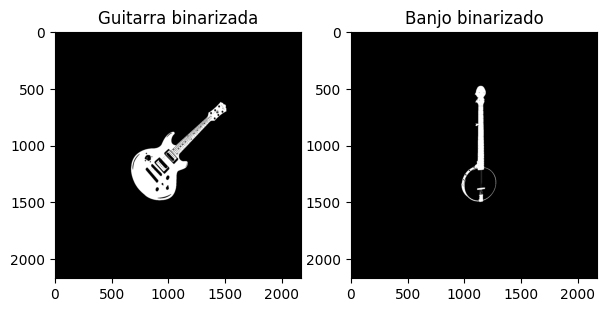

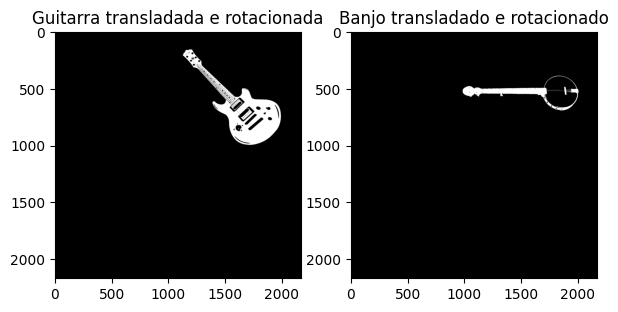

Momentos invariantes de Hu da guitarra:


,Imagem original,Transladada,Transladada + Rotacionada
phi1,1.642897e-03,1.642897e-03,1.642897e-03
phi2,1.297803e-06,1.297803e-06,1.297803e-06
phi3,5.429272e-09,5.429272e-09,5.429272e-09
phi4,3.441570e-09,3.441570e-09,3.441570e-09
phi5,1.487000e-17,1.487000e-17,1.487000e-17
phi6,3.892326e-12,3.892326e-12,3.892326e-12
phi7,-4.800000e-19,-4.800000e-19,-4.800000e-19



Momentos invariantes de Hu do banjo:


,Imagem original,Transladada,Transladada + Rotacionada
phi1,6.716230e-03,6.716230e-03,6.716230e-03
phi2,4.096737e-05,4.096737e-05,4.096737e-05
phi3,1.771791e-09,1.771791e-09,1.771791e-09
phi4,3.375228e-09,3.375228e-09,3.375228e-09
phi5,6.420000e-18,6.420000e-18,6.420000e-18
phi6,1.865144e-11,1.865144e-11,1.865144e-11
phi7,5.190000e-18,5.190000e-18,5.190000e-18



Momentos invariantes de Hu do violão:
 [[1.53971515e-03]
 [1.55590769e-06]
 [3.84650973e-09]
 [2.67354018e-09]
 [8.57360449e-18]
 [3.33486753e-12]
 [3.90237208e-21]]

Distância euclidiana, violão - guitarra: 0.00010318250403548325

Distância euclidiana, violão - banjo: 0.005176664587696851


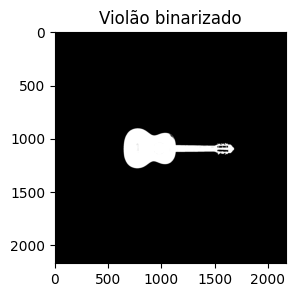

In [4]:
## -- Seu código começa AQUI -- ##

# Item 1 -----------------------------------------------------------------------------------------

# Carregando as imagens já em escala de cinza para possibilitar Otsu
guitarra = cv.imread('guitarra.png', cv.IMREAD_GRAYSCALE)
banjo = cv.imread('banjo.png', cv.IMREAD_GRAYSCALE)

# Binarizando as imagens pelo método de Otsu
thg, guitarra_bin = cv.threshold(guitarra, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
thb, banjo_bin = cv.threshold(banjo, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Obtendo o negativo das imagens
guitarra_bin = cv.bitwise_not(guitarra_bin)
banjo_bin = cv.bitwise_not(banjo_bin)

# Visualizando as imagens
plt.figure(figsize=(7, 4))

plt.subplot(1, 2, 1)
plt.imshow(guitarra_bin, 'gray')
plt.title('Guitarra binarizada')

plt.subplot(1, 2, 2)
plt.imshow(banjo_bin, 'gray')
plt.title('Banjo binarizado')

plt.show()

# Item 2 ------------------------------------------------------------------------------------------

# Transladando as imagens
T = np.float32([[1, 0, 500], [0, 1, 500]])  # Matriz de translação

guitarra_t = cv.warpAffine(guitarra_bin, T, guitarra_bin.shape)
banjo_t = cv.warpAffine(banjo_bin, T, banjo_bin.shape)

# Rotacionando as imagens já transladadas
guitarra_r = cv.rotate(guitarra_t, cv.ROTATE_90_COUNTERCLOCKWISE)
banjo_r = cv.rotate(banjo_t, cv.ROTATE_90_COUNTERCLOCKWISE)

# Visualizando as imagens
plt.figure(figsize=(7, 4))

plt.subplot(1, 2, 1)
plt.imshow(guitarra_r, 'gray')
plt.title('Guitarra transladada e rotacionada')

plt.subplot(1, 2, 2)
plt.imshow(banjo_r, 'gray')
plt.title('Banjo transladado e rotacionado')

plt.show()

# Item 3 ------------------------------------------------------------------------------------------

# Calculando os momentos invariantes de Hu para as imagens ORIGINAIS (binarizadas)
moments_guitarra = cv.moments(guitarra_bin)          # Momentos até terceira ordem
HuMoments_guitarra = cv.HuMoments(moments_guitarra)  # Momentos invariantes de Hu

moments_banjo = cv.moments(banjo_bin)                # Momentos até terceira ordem
HuMoments_banjo = cv.HuMoments(moments_banjo)        # Momentos invariantes de Hu

# Calculando os momentos invariantes de Hu para as imagens TRANSLADADAS
moments_guitarra_t = cv.moments(guitarra_t)
HuMoments_guitarra_t = cv.HuMoments(moments_guitarra_t)

moments_banjo_t = cv.moments(banjo_t)
HuMoments_banjo_t = cv.HuMoments(moments_banjo_t)

# Calculando os momentos invariantes de Hu para as imagens TRANSLADADAS E ROTACIONADAS
moments_guitarra_r = cv.moments(guitarra_r)
HuMoments_guitarra_r = cv.HuMoments(moments_guitarra_r)

moments_banjo_r = cv.moments(banjo_r)
HuMoments_banjo_r = cv.HuMoments(moments_banjo_r)

# Item 4 ---------------------------------------------------------------------------------------------

# Comparando os momentos de Hu das imagens originais com as suas versões transformadas

index_v = [f'phi{k}' for k in range(1,8)]  # Lista com os nomes phi1 até phi7

# Criando dicionários para as imagens da guitarra e do banjo, de modo a gerar um dataframe
d_guitarra = {'Imagem original': pd.Series(HuMoments_guitarra.flatten(), index=index_v),
              'Transladada': pd.Series(HuMoments_guitarra_t.flatten(), index=index_v),
              'Transladada + Rotacionada': pd.Series(HuMoments_guitarra_r.flatten(), index=index_v)}

d_banjo = {'Imagem original': pd.Series(HuMoments_banjo.flatten(), index=index_v),
          'Transladada': pd.Series(HuMoments_banjo_t.flatten(), index=index_v),
          'Transladada + Rotacionada': pd.Series(HuMoments_banjo_r.flatten(), index=index_v)}

# Criando os dataframes (tabelas para realizar comparações)
df_guitarra = pd.DataFrame(d_guitarra)
df_banjo = pd.DataFrame(d_banjo)

df_guitarra = df_guitarra.round(20)  # Mudando a precisão dos valores mostrados
df_banjo = df_banjo.round(20)

# Mostrando as tabelas
print(f'Momentos invariantes de Hu da guitarra:')
display(df_guitarra)
print(f'\nMomentos invariantes de Hu do banjo:')
display(df_banjo)

# Item 5 ---------------------------------------------------------------------------------------------

# Carregando a imagem em escala de cinza
violao = cv.imread('violao.png', cv.IMREAD_GRAYSCALE)

# Binarizando pelo método de Otsu
thv, violao_bin = cv.threshold(violao, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Obtendo o negativo da imagem
violao_bin = cv.bitwise_not(violao_bin)

# Visualizando a imagem
plt.figure(figsize=(3, 3))
plt.imshow(violao_bin, 'gray')
plt.title('Violão binarizado')

# Item 6 ---------------------------------------------------------------------------------------------

# Calculando os momentos invariantes de Hu da imagem binarizada
moments_violao = cv.moments(violao_bin)          # Momentos até terceira ordem
HuMoments_violao = cv.HuMoments(moments_violao)  # Momentos invariantes de Hu

print(f'\nMomentos invariantes de Hu do violão:\n {HuMoments_violao}')

# Item 7 ---------------------------------------------------------------------------------------------

# Distância euclidiana entre os vetores de momentos de Hu da imagem do violão em relação à da guitarra
vg_dist = np.linalg.norm(HuMoments_violao - HuMoments_guitarra)

# Distância euclidiana entre os vetores de momentos de Hu da imagem do violão em relação à do banjo
vb_dist = np.linalg.norm(HuMoments_violao - HuMoments_banjo)

# Printando tais distâncias
print(f'\nDistância euclidiana, violão - guitarra: {vg_dist}')
print(f'\nDistância euclidiana, violão - banjo: {vb_dist}')

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Item 4) Como foi possível perceber pelas tabelas que foram geradas, os momentos de Hu foram
# invariantes tanto para as imagens transladadas quanto para as transladadas e rotacionadas,
# em relação às imagens originais.
#
# Item 7) Como evidenciado pelos valores das duas distâncias euclidianas que foram mostrados,
# a distância entre o vetor de momentos de Hu da imagem do violão para a imagem da guitarra
# foi praticamente 50 vezes menor do que aquela entre violão e banjo. Dessa maneira, depreende-se
# que o formato da guitarra é bem mais próximo daquele do violão do que o é aquele do banjo, o que
# de fato corresponde à realidade. Sendo assim, pode-se afirmar que os momentos de Hu foram
# discriminantes, por permitirem diferenciar as imagens do banjo e da guitarra, aproximando mais a
# última à do violão.

### 3) Assinaturas (Nota: 2.0/10)

<center><figure class="half" style="display:flex">
    <img width="128" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/circulo1.png">
    <img width="128" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/circulo2.png">
    <img width="128" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/quadrado1.png">
    <img width="128" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/quadrado2.png">
    <figcaption><b> Figura 3: </b> Da esquerda para a direita: <i>circulo1.tif</i>, <i>circulo2.tif</i>, <i>quadrado1.tif</i> e <i>quadrado2.tif</i>.</b></figcaption>
</figure></center>

**Exercício:**

1. Utilize a função chamada `assinatura` que plota a assinatura de um contorno a partir do seu centro de massa ($\bar{x}$   e $\bar{y}$ calculados no exercício 1);

2. Aplique essa função para as imagens:

  *   `circulo1.tif`
  *   `circulo2.tif`
  *   `quadrado1.tif`
  *   `quadrado2.tif`

3. Mostre o resultado utilizando um `subplot` de tamanho (1,2), onde o primeiro deve mostrar a imagem original e o segundo a respectiva assinatura.
  * Estipule os valores de escala mostrados abaixo (função `plt.axis`) para os eixos `rho` e `theta` ao plotar cada uma das assinaturas.
  ```python
  plt.plot(theta,rho,'.')
  plt.axis([-180, 180, 0, 150])
  plt.show()
  ```


4. Além disso, plote um '+' no centro de massa da imagem.

5. Compare e comente os resultados obtidos.

6. Com base nos resultados referente aos círculos, o que se pode concluir em relação à função assinatura e a forma como detecta a borda/fronteira do objeto?

<b>Dicas:</b>


* Mostre o *plote* da assinatura com "pontos", utilizando a função `plt.plot` com o argumento ` '.' ` . Veja o exemplo abaixo.
``` python
rho,theta = assinatura(img,cX,cY)
plt.plot(rho,theta,'.')
```

* Para colocar um '+' no centro de massa, utilize um `plt.plot` após mostrar a imagem.
``` python
# Mostra a imagem
plt.imshow(myImg, 'gray')
# Coloca um '+' no centro de massa
plt.plot(ic, jc, '+')
```


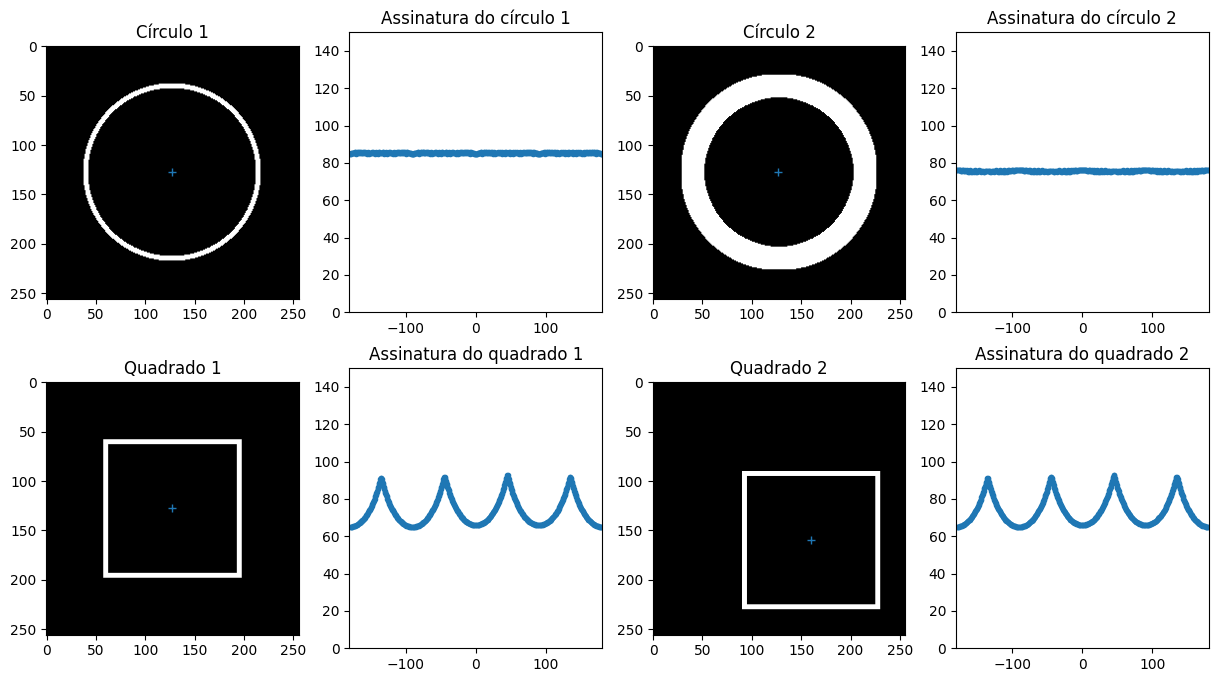

In [5]:
def assinatura(img, ic, jc):
  '''
  Descrição: Cria assinatura para uma imagem.

  Entrada:
    - img: Imagem de entrada (uint8).
    - ic: Coordenada X do centro de massa normalizado (uint8).
    - jc: Coordenada Y do centro de massa normalizado (uint8).

  Saída:
    - rho: Coordenadas polar (rho) dos pontos [range=0:img.shape[0]*np.sqrt(2)/2].
    - theta: Coordenadas polar (theta) dos pontos [range=-180:180].
  '''
  # Sistema de coordenadas
  # .__> jj (y)
  # |
  # v
  # ii (x)

  # Teste de insanidade
  if img.ndim != 2:
    raise ValueError('Imagem deve ter 2 dimensões.')

  # Varre a imagem, determinando as coordenadas dos pontos brancos

  contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_NONE)

  # Translada a origem do sistema de coordenadas para o centro de massa

  img_copy = np.zeros(img.shape)

  cv.drawContours(image=img_copy, contours=contours, contourIdx=1, color=(255, 255, 255), thickness=1, lineType=cv.LINE_AA)


  ii,jj = np.nonzero(img_copy)
  ii -= np.int32(ic)
  jj -= np.int32(jc)
  # Converte as novas coordenadas cartesianas para coordenadas polares
  rho = np.sqrt(ii**2 + jj**2)
  theta = np.rad2deg(np.arctan2(jj, ii))

  return rho, theta

## -- Seu código começa AQUI -- ##

# Item 1 -------------------------------------------------------------------------------------------------------------

# Carregando as imagens
circulo1 = cv.imread('circulo1.tif', cv.IMREAD_GRAYSCALE)
circulo2 = cv.imread('circulo2.tif', cv.IMREAD_GRAYSCALE)
quadrado1 = cv.imread('quadrado1.tif', cv.IMREAD_GRAYSCALE)
quadrado2 = cv.imread('quadrado2.tif', cv.IMREAD_GRAYSCALE)

# Calculando as coordenadas dos CMs das imagens, utilizando a função momentos do exercício 1

# Obtendo os momentos de cada imagem
mc1 = momentos(circulo1)
mc2 = momentos(circulo2)
mq1 = momentos(quadrado1)
mq2 = momentos(quadrado2)

# Calculando os centros de massa para cada imagem
cmc1 = [mc1[2]/mc1[0], mc1[1]/mc1[0]]  # CM Círculo 1
cmc2 = [mc2[2]/mc2[0], mc2[1]/mc2[0]]  # CM Círculo 2
cmq1 = [mq1[2]/mq1[0], mq1[1]/mq1[0]]  # CM Quadrado 1
cmq2 = [mq2[2]/mq2[0], mq2[1]/mq2[0]]  # CM Quadrado 2

ic1, jc1 = cmc1[0], cmc1[1]  # Coordenadas CM Círculo 1
ic2, jc2 = cmc2[0], cmc2[1]  # Coordenadas CM Círculo 2
iq1, jq1 = cmq1[0], cmq1[1]  # Coordenadas CM Quadrado 1
iq2, jq2 = cmq2[0], cmq2[1]  # Coordenadas CM Quadrado 2

# Item 2 -------------------------------------------------------------------------------------------------------------

# Aplicando a função assinatura nas imagens
rho_c1, theta_c1 = assinatura(circulo1, ic1, jc1)  # Círculo 1
rho_c2, theta_c2 = assinatura(circulo2, ic2, jc2)  # Círculo 2
rho_q1, theta_q1 = assinatura(quadrado1, iq1, jq1)  # Quadrado 1
rho_q2, theta_q2 = assinatura(quadrado2, iq2, jq2)  # Quadrado 2

# Itens 3 e 4 --------------------------------------------------------------------------------------------------------

# Arrays de legenda
leg1 = ['Círculo 1', 'Círculo 2', 'Quadrado 1', 'Quadrado 2']
leg2 = ['Assinatura do círculo 1', 'Assinatura do círculo 2', 'Assinatura do quadrado 1', 'Assinatura do quadrado 2']

# Arrays das imagens e das coordenadas, para faciltar a plotagem
imgs = [circulo1, circulo2 , quadrado1, quadrado2]
rho, theta = [rho_c1, rho_c2, rho_q1, rho_q2], [theta_c1, theta_c2, theta_q1, theta_q2]
cm_i, cm_j = [ic1, ic2, iq1, iq2], [jc1, jc2, jq1, jq2]

# Plotando as imagens com suas assinaturas
plt.figure(figsize=(15,8))

c = 0

for k, img in enumerate(imgs):

  c += 1

  plt.subplot(2, 4, c)
  plt.imshow(img, 'gray')
  plt.plot(cm_j[k], cm_i[k], '+')
  plt.title(leg1[k])

  c += 1

  plt.subplot(2, 4, c)
  plt.plot(theta[k], rho[k], '.')
  plt.title(leg2[k])
  plt.axis([-180, 180, 0, 150])

plt.show()

# Item 5 ------------------------------------------------------------------------------------------------------------

# Como é possível perceber, a assinatura da imagem não varia com a translação, como foi o caso dos quadrados, mas
# varia com a forma, como evidenciado pelo conjunto de círculos, no qual as assinaturas estão deslocadas entre si,
# já que as espessuras dos círculos são diferentes.

# Item 6 ------------------------------------------------------------------------------------------------------------

# Analisando as assinaturas dos círculos, conjuntamente às imagens, pode-se perceber que a assinatura se encontra, no
# eixo y, no valor correspondente ao raio interno dos círculos. O raio interno do círculo 1 é aproximadamente 85,
# enquanto o do círculo 2, pouco mais de 75. Dessa forma, tem-se que a função assinatura detecta a borda a partir do
# centro de massa da imagem. Pegando um vetor raio que saia do CM de cada círculo, o primeiro encontro dele é com a
# borda interna, que é a que é detectada.

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Realizados nos itens 5 e 6 acima


### 4) *Local Binnary Patterns* (LBP) (Nota: 2.0/10)

<center><figure class="half" style="display:flex">
    <img width="200" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex1.png">
    <img width="200" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex2.png">
    <img width="200" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex3.png">
    <img width="200" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/tex4.png">
    <figcaption><b> Figura 4: </b> Da esquerda para a direita: feijão, macarrão, arroz e arroz novamente.</figcaption>
</figure></center>

**Exercício:**

1. Calcule os mapas de textura por padrões binários locais (LBP) das imagens `tex1.tiff`, `tex2.tiff` e `tex3.tiff`, apresentadas anteriormente. Cada uma representa a imagem de um alimento (feijão, macarrão, arroz). Considere raio 1 e 8 vizinhos, e utilize o método por 'default': LBP circular original;

2. Apresente os mapas de texturas calculados (imagens) e o histograma correpondente a cada um;

3. Carregue a imagem `tex4.tiff`, e também apresente o seu mapa de textura e o seu histograma LBP.

4. Calcule a distância euclidiana **entre os histogramas** LBP de cada imagem e o **histograma** da imagem `tex4.tiff`. A distância euclidiana nesse caso está sendo utilizada como métrica de similaridade. Classifique a qual dos três tipos de textura a imagem `tex4.tiff` pertence;

4. Varie o raio, o número de pontos e o método utilizado para o 'rot': versão que lida com variação da rotação; e verifique como a distância entre os histogramas varia, se descrevem melhor as amostras da mesma classe.


<font size="3" color="darkblue"><b>Dicas:</b></font>


* Utilize a função [local_binary_pattern](https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=lbp#skimage.feature.local_binary_pattern) da biblioteca `scikit-image.feature` para calcular o LBP.

* Utilize a função [np.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) da biblioteca `numpy.linalg` para calcular a distância entre os vetores.

*Ex:*
``` python
# P correspondendo aos pontos e R ao raio.
image_LBP = local_binary_pattern(myImg, P, R, method='default')

L2_distance = np.linalg.norm(vetor_diferenca_entre_histogramas)
```

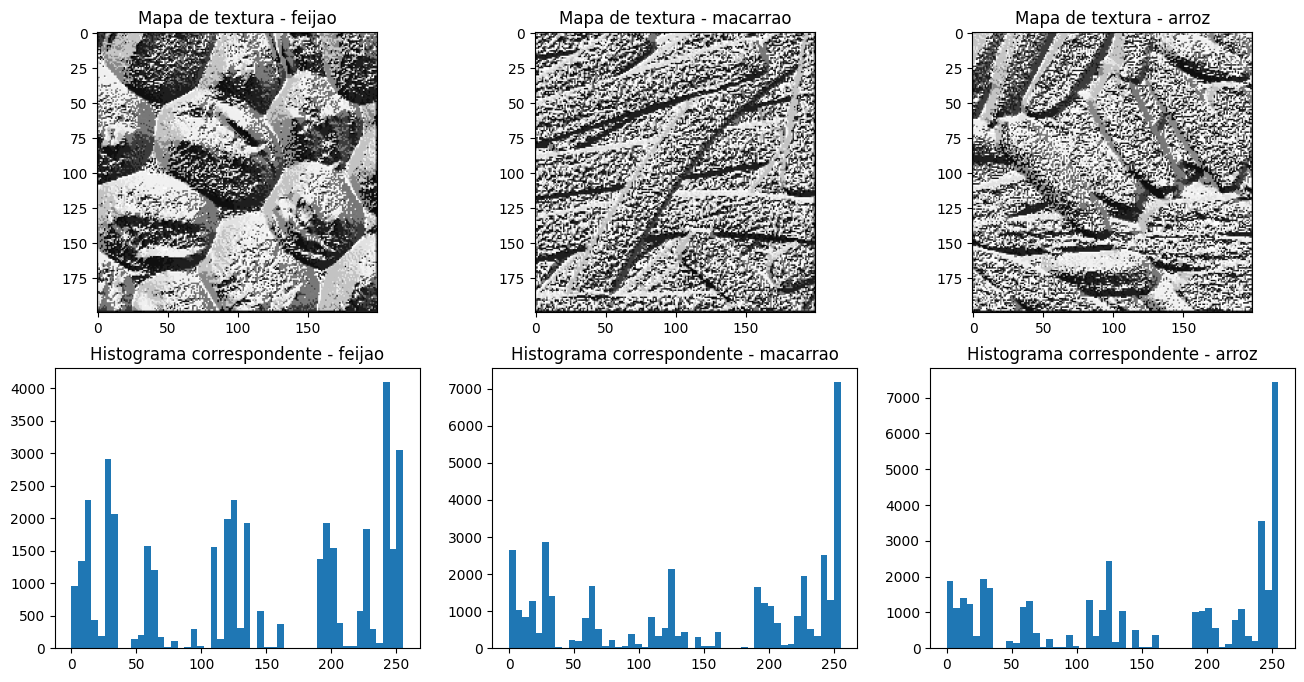

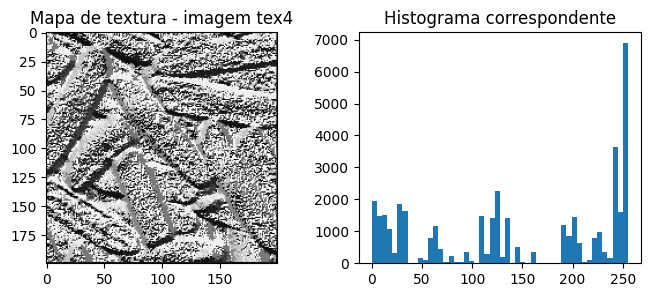


Distâncias euclidianas entre os histogramas:

Distância entre os histogramas do feijão e a imagem tex4: 4655.782640974555

Distância entre os histogramas do macarrão e a imagem tex4: 2744.6890534266354

Distância entre os histogramas do arroz e a imagem tex4: 1073.0479951987236

Tendo em vista que a menor distância euclidiana se deu entre arroz e a imagem tex4, tem-se que essa última imagem corresponde à textura do arroz

Distâncias euclidianas entre os histogramas das imagens e da imagem tex4, variando-se R e N



,Feijão - tex4,Macarrão - tex4,Arroz - tex4
"R = 1, N = 4",25433.936915,22344.392921,22162.517659
"R = 1, N = 8",16931.369141,9387.635432,10571.152586
"R = 1, N = 16",4210.334310,2598.051385,2297.250531
"R = 2, N = 4",28142.079436,23446.652106,23881.740619
"R = 2, N = 8",18109.086531,9165.419739,11283.827143
"R = 2, N = 16",5916.348113,2637.359854,442.959366
"R = 3, N = 4",29118.724337,23870.777428,24628.173846
"R = 3, N = 8",18203.360981,9428.013948,11618.749718
"R = 3, N = 16",6215.800753,2836.611182,0.000000


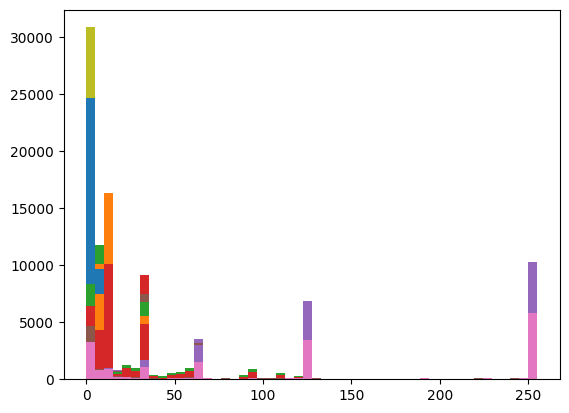

In [6]:
## -- Seu código começa AQUI -- ##

# Item 1 --------------------------------------------------------------------------------------

# Carregando as imagens
feijao = cv.imread('tex1.tiff', cv.IMREAD_GRAYSCALE)
macarrao = cv.imread('tex2.tiff', cv.IMREAD_GRAYSCALE)
arroz = cv.imread('tex3.tiff', cv.IMREAD_GRAYSCALE)

# Calculando os mapas de textura por padrões binários locais (LBP) para cada imagem
feijao_LBP = local_binary_pattern(feijao, 8, 1, method='default')
macarrao_LBP = local_binary_pattern(macarrao, 8, 1, method='default')
arroz_LBP = local_binary_pattern(arroz, 8, 1, method='default')

# Item 2 --------------------------------------------------------------------------------------

# Arrays para facilitar a plotagem das imagens e dos histogramas
nome = ['feijao', 'macarrao', 'arroz']
imgs = [feijao_LBP, macarrao_LBP, arroz_LBP]
leg1 = [f'Mapa de textura - {img}' for img in nome]
leg2 = [f'Histograma correspondente - {img}' for img in nome]

# Array que armazenará os histogramas
hists = list()

# Plotando as imagens e os histogramas
plt.figure(figsize=(16, 8))

for k, img in enumerate(imgs):

  # Mapas de textura
  plt.subplot(2, 3, k + 1)
  plt.imshow(img, 'gray')
  plt.title(leg1[k])

  # Histogramas
  plt.subplot(2, 3, k + 4)
  h = plt.hist(img.flatten(), bins=50, density=False, range=(0,255))
  hists.append(h)
  plt.title(leg2[k])

plt.show()

# Item 3 --------------------------------------------------------------------------------------

# Carregando a imagem
tex4 = cv.imread('tex4.tiff', cv.IMREAD_GRAYSCALE)

# Calculando o mapa de textura por padrões binários locais (LBP) para a imagem
tex4_LBP = local_binary_pattern(tex4, 8, 1, method='default')

# Plotando o mapa de textura e o histograma associado
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(tex4_LBP, 'gray')
plt.title('Mapa de textura - imagem tex4')

plt.subplot(1, 2, 2)
h = plt.hist(tex4_LBP.flatten(), bins=50, density=False, range=(0,255))
plt.title('Histograma correspondente')

plt.show()

# Item 4 --------------------------------------------------------------------------------------

# Array que armazenará as distâncias euclidianas
dists = list()

# Calculando as distâncias e armazenando no array anterior
for k, hist in enumerate(hists):
  dists.append(np.linalg.norm(hist[0] - h[0]))

# Printando as distâncias
print('\nDistâncias euclidianas entre os histogramas:')
print(f'\nDistância entre os histogramas do feijão e a imagem tex4: {dists[0]}')
print(f'\nDistância entre os histogramas do macarrão e a imagem tex4: {dists[1]}')
print(f'\nDistância entre os histogramas do arroz e a imagem tex4: {dists[2]}')

# Concluindo sobre o tipo de textura da imagem arroz 2
print(f'\nTendo em vista que a menor distância euclidiana se deu entre ' +
       'arroz e a imagem tex4, tem-se que essa última imagem corresponde à textura do arroz')

# Item 5 --------------------------------------------------------------------------------------

# Array de valores para o raio e número de pontos
rs, ns = [1, 2, 3], [4, 8, 16]

# Lista que armazenará os histogramas
hists_l = list()

# Lista auxiliar de distâncias
dists_aux = list()

# Lista que armazenará as listas de distâncias euclidianas
dists_l = list()

# Lista das imagens originais
imgs_originais = [feijao, macarrao, arroz]

# Calculando os mapas de textura para os diferentes valores de P e R
for r in rs:
  for n in ns:
    for img in imgs_originais:
      img_LBP = local_binary_pattern(img, n, r, method='ror')
      h = plt.hist(img_LBP.flatten(), bins=50, range=(0,255))
      hists_l.append(h)

# Calculando as distâncias euclidianas e armazenando em dists_l

c = 0  # Contador

for hist in hists_l:

  c += 1

  dists_aux.append(np.linalg.norm(hist[0] - h[0]))  # Armazena a distância em dists_aux

  # Após cada grupo de 3, a lista aux é armazenada em dists_l e depois esvaziada
  if c % 3 == 0:
    dists_l.append(dists_aux)
    dists_aux = list()

# Criando um DataFrame para comparar as distâncias euclidianas

index_v = [f'R = {r}, N = {n}' for r in rs for n in ns]  # Lista com o título das linhas

# Criando o dicionário que será usado no DataFrame
d = {'Feijão - tex4': pd.Series([dist[0] for dist in dists_l], index=index_v),
     'Macarrão - tex4': pd.Series([dist[1] for dist in dists_l], index=index_v),
     'Arroz - tex4': pd.Series([dist[2] for dist in dists_l], index=index_v)}

# Criando o DataFrame e mostrando-o
df = pd.DataFrame(d)

print('\nDistâncias euclidianas entre os histogramas das imagens e da imagem tex4, variando-se R e N\n')
display(df)

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Item 5) Em primeira instância, pode-se observar que, variando-se apenas o método de 'default' para 'rot',
# mantendo N=8 e R=1, tem-se que para o método 'default' o resultado foi mais satisfatório, já que a menor
# distância foi obtida entre tex4 (que nada mais é do que arroz também) e a imagem do arroz, enquanto 'rot'
# conferiu maior semelhança ao macarrão.
# Mantendo-se fixo o método 'rot' e variando-se N e R, pode-se perceber que, para N=8, todas as menores
# distâncias foram creditadas ao macarrão bem como para N=4 com R=2 ou R=3. Os resultados mais discriminantes,
# porém, foram obtidos com N=16, sobretudo para R=2 e R=3.

### 5) Descritor de cor (Nota: 2.5/10)

Esse exercício tem como objetivo obter um descritor sobre as folhas de café.



 <center><figure class="half" style="display:flex">
    <img width="300" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/folha_ferrugem.png">
    <img width="300" src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_04/folha_saudavel.png">
 </figure>   
    <figcaption><b> Figura 5: </b> Da esquerda para a direita: Folha com ferrugem  e folha saudável.</figcaption>
</center>


1. Extraia os canais R, G e B da imagem `folha_ferrugem.png`;

Como a ferrugem, nesse caso, possui pigmentação alaranjada, os canais R e G possuirão altos valores de intensidade nos pontos de ferrugem enquanto que o canal B terá baixos valores de intensidade.

2. Visualize os canais R, G e B separadamente, em escala de cinza.

4. Proponha, então, uma máscara binária $M(x)$ para os canais R, G e B (separadamente) de forma que, ao fazer alguma operação lógica com essas três máscaras dos canais, seja possível obter uma máscara que contenha os pixels de iteresse (ferrugem).
  * Você deve propor os thresholds bem como a operação lógica.

3. Mostre cada matriz binária dos canais e a resultante da operação.

4. Por fim, faça um descritor para a relação entre pixel de ferrugem $P_{fr}$ e pixel de folha $P_{fl}$:

  \begin{equation}
  Cor_{\gamma}(\%) = \frac{P_{fr}}{P_{fl}}
  \end{equation}

5. Agora, aplique exatamente o mesmo passo a passo que você propôs anteriormente na imagem `folha_saudavel.png`. Seu descritor foi bem sucessido? Comente.

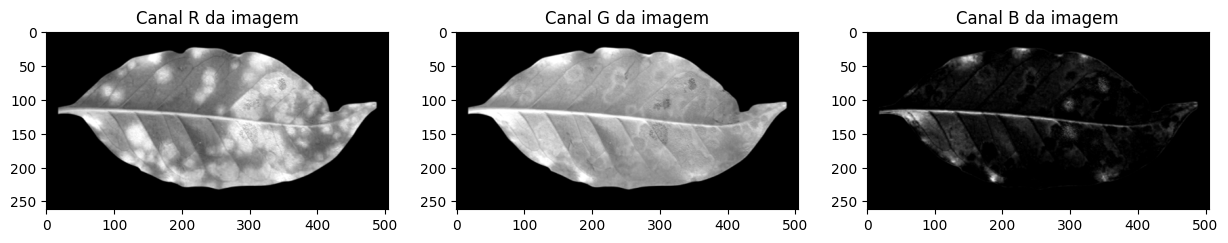

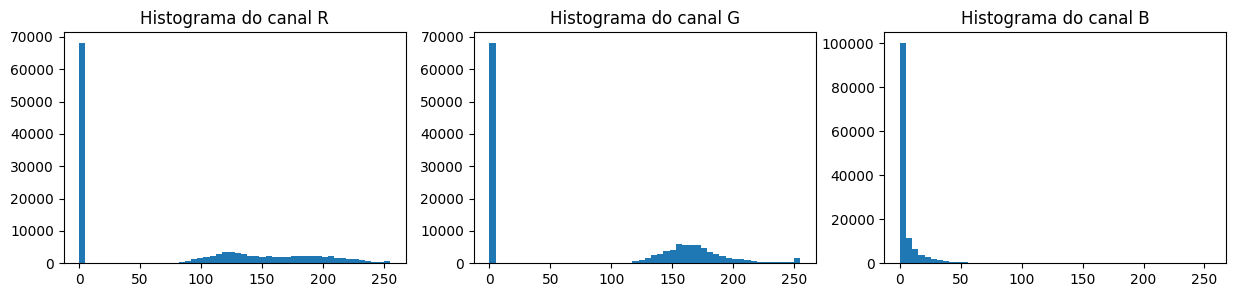

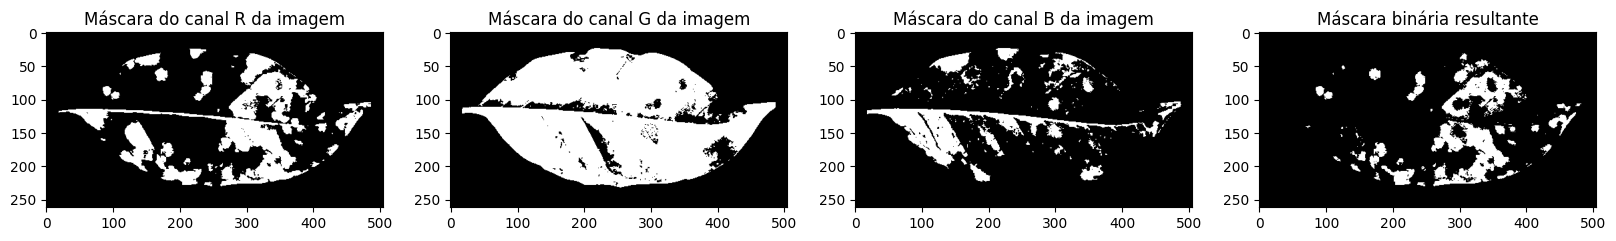


Cor(%): 19.469232199293547 %
##########################################################################################################################################


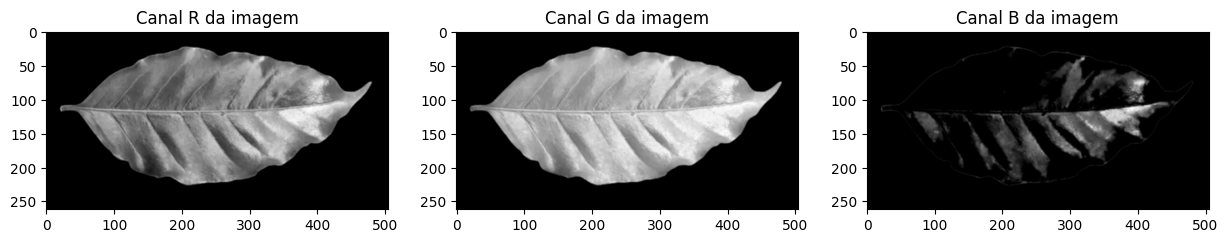

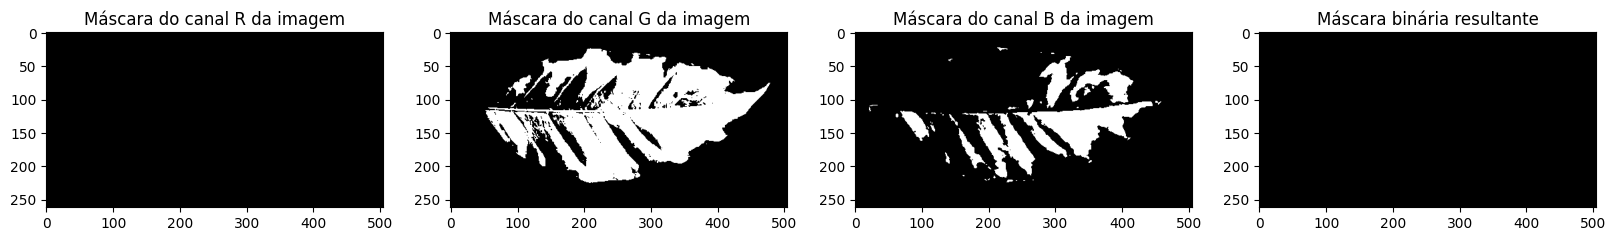


Cor(%): 0.0 %


In [7]:
## -- Seu código começa AQUI -- ##

# Item 1 ----------------------------------------------------------------------------------------

# Carregando a imagem
img = cv.imread('folha_ferrugem.png')

# Separando os canais R, G e B
b, g, r = cv.split(img)

# Item 2 ----------------------------------------------------------------------------------------

# Plotando os canais R, G e B separadamente
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(r, 'gray')
plt.title('Canal R da imagem')

plt.subplot(1, 3, 2)
plt.imshow(g, 'gray')
plt.title('Canal G da imagem')

plt.subplot(1, 3, 3)
plt.imshow(b, 'gray')
plt.title('Canal B da imagem')

plt.show()

# Item 3 -----------------------------------------------------------------------------------------

# Plotando os histogramas de cada imagem para ajudar na decisão dos thresholds
plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
hr = plt.hist(r.flatten(), bins=50, density=False, range=(0,255))
plt.title('Histograma do canal R')

plt.subplot(1, 3, 2)
hg = plt.hist(g.flatten(), bins=50, density=False, range=(0,255))
plt.title('Histograma do canal G')

plt.subplot(1, 3, 3)
hb = plt.hist(b.flatten(), bins=50, density=False, range=(0,255))
plt.title('Histograma do canal B')

plt.show()

# Propondo os thresholds
thr = 180
thg = 140
thb = 15

# Aplicando a máscara binária com os thresholds anteriores
thr_f, rbin = cv.threshold(r, thr, 255, cv.THRESH_BINARY)  # Máscara para o canal R
thg_f, gbin = cv.threshold(g, thg, 255, cv.THRESH_BINARY)  # Máscara para o canal G
thb_f, bbin = cv.threshold(b, thb, 255, cv.THRESH_BINARY)  # Máscara para o canal B

# Realizando a operação lógica para obter a máscara final (Mr & Mg & !Mb)
img_final = np.bitwise_and(rbin, np.bitwise_and(gbin, np.bitwise_not(bbin)))

# Item 4 -----------------------------------------------------------------------------------------

# Mostrando a máscara binária de cada canal, bem como a máscara final
plt.figure(figsize=(20, 4))

plt.subplot(1, 4, 1)
plt.imshow(rbin, 'gray')
plt.title('Máscara do canal R da imagem')

plt.subplot(1, 4, 2)
plt.imshow(gbin, 'gray')
plt.title('Máscara do canal G da imagem')

plt.subplot(1, 4, 3)
plt.imshow(bbin, 'gray')
plt.title('Máscara do canal B da imagem')

plt.subplot(1, 4, 4)
plt.imshow(img_final, 'gray')
plt.title('Máscara binária resultante')

plt.show()

# Item 5 -----------------------------------------------------------------------------------------

# Obtendo o número de pixels de ferrugem de acordo com a máscara final encontrada anteriormente
nfr = 0
for pixel in img_final.flatten():
  if pixel == 255:
    nfr += 1

# Obtendo o número total de pixels da imagem original (folha)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # Passando a imagem para escala de cinza

nfl = 0
for pixel in img_gray.flatten():
  if pixel != 0:
    nfl += 1

# Calculando o descritor de cor
cor = nfr/nfl

# Printando o resultado
print(f'\nCor(%): {cor*100} %')

# Item 6 ------------------------------------------------------------------------------------------

print('##########################################################################################################################################')

# Carregando a imagem
img2 = cv.imread('folha_saudavel.png')

# Separando os canais R, G e B
b2, g2, r2 = cv.split(img2)

# Plotando os canais R, G e B separadamente
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(r2, 'gray')
plt.title('Canal R da imagem')

plt.subplot(1, 3, 2)
plt.imshow(g2, 'gray')
plt.title('Canal G da imagem')

plt.subplot(1, 3, 3)
plt.imshow(b2, 'gray')
plt.title('Canal B da imagem')

plt.show()

# Aplicando a máscara binária com os thresholds anteriores (os mesmos, já que foi
# pedido exatamente o mesmo processo)
thr_f, rbin2 = cv.threshold(r2, thr, 255, cv.THRESH_BINARY)  # Máscara para o canal R
thg_f, gbin2 = cv.threshold(g2, thg, 255, cv.THRESH_BINARY)  # Máscara para o canal G
thb_f, bbin2 = cv.threshold(b2, thb, 255, cv.THRESH_BINARY)  # Máscara para o canal B

# Realizando a operação lógica para obter a máscara final (Mr & Mg & !Mb)
img_final2 = np.bitwise_and(rbin2, np.bitwise_and(gbin2, np.bitwise_not(bbin2)))

# Mostrando a máscara binária de cada canal, bem como a máscara final
plt.figure(figsize=(20, 4))

plt.subplot(1, 4, 1)
plt.imshow(rbin2, 'gray')
plt.title('Máscara do canal R da imagem')

plt.subplot(1, 4, 2)
plt.imshow(gbin2, 'gray')
plt.title('Máscara do canal G da imagem')

plt.subplot(1, 4, 3)
plt.imshow(bbin2, 'gray')
plt.title('Máscara do canal B da imagem')

plt.subplot(1, 4, 4)
plt.imshow(img_final2, 'gray')
plt.title('Máscara binária resultante')

plt.show()

# Obtendo o número de pixels de ferrugem de acordo com a máscara final encontrada anteriormente
nfr2 = 0
for pixel in img_final2.flatten():
  if pixel == 255:
    nfr2 += 1

# Calculando o descritor de cor
cor2 = nfr2/nfl

# Printando o resultado
print(f'\nCor(%): {cor2*100} %')

# Seu descritor foi bem sucedido? Comente.
#
# Tendo em vista que o descritor apontou 0.0% de ferrugem para a imagem saudável, pode-se concluir
# que foi bem sucedido. Como a ferrugem possui coloração amarela, ela possui alta intensidade nos
# canais R e G, enquanto possui baixa intensidade no canal B. Sendo assim, a operação lógica
# realizada (R & G & !B) consegue captar justamente os pixels correspondentes à ferrugem, como pôde
# ser observado na imagem final da primeira parte, com o descritor tendo apontado 19.47% de ferrugem.
# Ao ser aplicado na imagem saudável, como não se tem a coloração amarela, o descritor resulta 0.

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Para a proposição dos thresholds, inicialmente utilizou-se os histogramas para ter uma noção de um
# valor inicial para cada threshold. Em seguida, foi-se ajustando os mesmos, visando obter o que era
# requerido, ou seja, branco nas regiões de ferrugem para os canais R e G, e preto nas regiões de
# ferrugem para o canal B. Não se obteve valores perfeitos, mas se mostraram satisfatótios.
